# ☕ EDA — Coffee Quality Classification
### Proyecto Grupal — Clasificación de Calidad de Café

---

## 📖 ¿Qué es un EDA y para qué sirve?

El **Análisis Exploratorio de Datos (EDA)** es el primer paso de todo proyecto de Machine Learning.  
Antes de entrenar cualquier modelo, necesitamos **entender** los datos:
- ¿Qué hay en el dataset?
- ¿Los datos están limpios o tienen errores?
- ¿Qué variables son importantes?
- ¿Hay patrones o relaciones entre variables?

**Analogía:** El EDA es como leer el manual de instrucciones antes de montar un mueble. Puedes saltártelo, pero luego te sobran tornillos.

---

## 🗺️ Hoja de Ruta del Notebook

| Bloque | Qué vamos a hacer |
|--------|-------------------|
| **0** | Importar librerías y cargar datos |
| **1** | Primera inspección del dataset |
| **2** | Análisis de valores nulos |
| **3** | Crear la variable objetivo (target) |
| **4** | Análisis de variables numéricas (sensoriales) |
| **5** | Análisis de variables categóricas (origen, proceso) |
| **6** | Correlaciones entre variables |
| **7** | Detección de outliers |
| **8** | Conclusiones y próximos pasos |

---

> ⚠️ **Importante:** Ejecuta las celdas en orden, de arriba a abajo. Cada celda depende de la anterior.

---
## 📦 BLOQUE 0 — Importar librerías y cargar el dataset

**¿Qué son las librerías?**  
Son colecciones de funciones ya escritas por otros que podemos reutilizar.  
- `pandas` → manipular tablas de datos  
- `numpy` → cálculos matemáticos  
- `matplotlib` y `seaborn` → crear gráficos  
- `warnings` → ocultar avisos que no nos interesan

In [1]:
# ─── Cargar de librerías  ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  # Cambiado de 'as plt' a 'pyplot as plt'
import seaborn as sns             # El estándar es 'sns' en lugar de 'sn'

# Configuración de visualización de Pandas
# CONFIGURACIÓN PARA VER TODO
pd.set_option('display.max_columns', None)  # Muestra todas las columnas en head/describe
pd.set_option('display.max_rows', 50)       # No satura el notebook con miles de filas

In [2]:
# ─── Cargar el dataset ────────────────────────────────────────────────────────
# 📌 ACCIÓN: Cambia la ruta al lugar donde tienes guardado el CSV
# Descarga el dataset desde: https://www.kaggle.com/datasets/fatihb/coffee-quality-data-cqi
#La ruta no modificarla. Y poner el mismo nombre todos.

df = pd.read_csv('/content/coffee_quality_fusionado.csv')

print(f'✅ Dataset cargado correctamente')
print(f'📊 Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')

df.head()

✅ Dataset cargado correctamente
📊 Dimensiones: 1512 filas x 38 columnas


,Acidity,Aftertaste,Aroma,Bag Weight,Balance,Body,Category One Defects,Category Two Defects,Certification Address,Certification Body,Certification Contact,Clean Cup,Color,Company,Country of Origin,Expiration,Farm Name,Flavor,Grading Date,Harvest Year,ICO Number,In-Country Partner,Lot Number,Mill,Moisture Percentage,Number of Bags,Overall,Owner,Processing Method,Producer,Quakers,Region,Sweetness,Total Cup Points,Uniformity,Variety,altitud_limpia,dataset_source
0,8.75,8.67,8.67,60 kg,8.42,8.50,0,0,309fcf77415a3661ae83e027f7e5f05dad786e44,METAD Agricultural Development plc,19fef5a731de2db57d16da10287413f5f99bc2dd,10.0,Green,metad agricultural developmet plc,Ethiopia,"April 3rd, 2016",metad plc,8.83,"April 4th, 2015",2014,2014/2015,METAD Agricultural Development plc,NaN,metad plc,0.12,300,8.75,metad plc,Washed / Wet,METAD PLC,0.0,guji-hambela,10.0,90.58,10.0,NaN,2075.0,2018_volpatto
1,8.58,8.50,8.75,60 kg,8.42,8.42,0,1,309fcf77415a3661ae83e027f7e5f05dad786e44,METAD Agricultural Development plc,19fef5a731de2db57d16da10287413f5f99bc2dd,10.0,Green,metad agricultural developmet plc,Ethiopia,"April 3rd, 2016",metad plc,8.67,"April 4th, 2015",2014,2014/2015,METAD Agricultural Development plc,NaN,metad plc,0.12,300,8.58,metad plc,Washed / Wet,METAD PLC,0.0,guji-hambela,10.0,89.92,10.0,Other,2075.0,2018_volpatto
2,8.42,8.42,8.42,1,8.42,8.33,0,0,36d0d00a3724338ba7937c52a378d085f2172daa,Specialty Coffee Association,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,10.0,NaN,NaN,Guatemala,"May 31st, 2011","san marcos barrancas ""san cristobal cuch",8.50,"May 31st, 2010",NaN,NaN,Specialty Coffee Association,NaN,NaN,0.00,5,9.25,grounds for health admin,NaN,NaN,0.0,NaN,10.0,89.75,10.0,Bourbon,1700.0,2018_volpatto
3,8.42,8.42,8.17,60 kg,8.25,8.50,0,2,309fcf77415a3661ae83e027f7e5f05dad786e44,METAD Agricultural Development plc,19fef5a731de2db57d16da10287413f5f99bc2dd,10.0,Green,yidnekachew debessa coffee plantation,Ethiopia,"March 25th, 2016",yidnekachew dabessa coffee plantation,8.58,"March 26th, 2015",2014,NaN,METAD Agricultural Development plc,NaN,wolensu,0.11,320,8.67,yidnekachew dabessa,Natural / Dry,Yidnekachew Dabessa Coffee Plantation,0.0,oromia,10.0,89.00,10.0,NaN,2000.0,2018_volpatto
4,8.50,8.25,8.25,60 kg,8.33,8.42,0,2,309fcf77415a3661ae83e027f7e5f05dad786e44,METAD Agricultural Development plc,19fef5a731de2db57d16da10287413f5f99bc2dd,10.0,Green,metad agricultural developmet plc,Ethiopia,"April 3rd, 2016",metad plc,8.50,"April 4th, 2015",2014,2014/2015,METAD Agricultural Development plc,NaN,metad plc,0.12,300,8.58,metad plc,Washed / Wet,METAD PLC,0.0,guji-hambela,10.0,88.83,10.0,Other,2075.0,2018_volpatto


---
## 🔍 BLOQUE 1 — Primera inspección del dataset

**Objetivo:** Entender qué hay dentro del dataset sin entrar en detalles todavía.  
Es como abrir una caja y ver qué hay dentro antes de sacar nada.

**Preguntas que vamos a responder:**
- ¿Cuántas filas y columnas tiene?
- ¿Qué significa cada columna?
- ¿Qué tipo de dato tiene cada columna (número, texto, fecha)?

In [3]:
# Ver las primeras 5 filas del dataset (head)
# Esto nos da una idea visual de cómo están organizados los datos
df.head(5)
df.tail(3)
df.sample(10)


,Acidity,Aftertaste,Aroma,Bag Weight,Balance,Body,Category One Defects,Category Two Defects,Certification Address,Certification Body,Certification Contact,Clean Cup,Color,Company,Country of Origin,Expiration,Farm Name,Flavor,Grading Date,Harvest Year,ICO Number,In-Country Partner,Lot Number,Mill,Moisture Percentage,Number of Bags,Overall,Owner,Processing Method,Producer,Quakers,Region,Sweetness,Total Cup Points,Uniformity,Variety,altitud_limpia,dataset_source
1440,7.58,7.50,7.67,100 kg,7.50,7.58,0,0,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...",Taiwan Coffee Laboratory 台灣咖啡研究室,"Lin, Jen-An Neil 林仁安 - 886-289116612",10.00,Blue-Green,Taiwu Coffee Cooperative,Taiwan,"January 6th, 2024",迎曦山丘,7.67,"January 6th, 2023",2021 / 2022,NaN,Taiwan Coffee Laboratory 台灣咖啡研究室,A20-Northern Taiwan Specialty Coffee Evaluation,迎曦山丘,11.80,1,7.67,Taiwu,Washed / Wet,翁召安,0.0,苗栗縣,10.0,83.17,10.00,Unknown,340.00,2023_fatihb
879,8.00,7.67,7.42,5 lbs,7.50,7.58,0,4,36d0d00a3724338ba7937c52a378d085f2172daa,Specialty Coffee Association,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,9.33,Green,sustainable harvest,Mexico,"April 2nd, 2015",NaN,7.42,"April 2nd, 2014",2014,016-2022-0009,Specialty Coffee Association,NaN,NaN,0.00,320,7.42,dane loraas,Washed / Wet,Huatusco,0.0,veracruz,10.0,81.67,9.33,NaN,NaN,2018_volpatto
855,7.50,7.33,7.00,2 kg,7.33,7.50,0,0,36d0d00a3724338ba7937c52a378d085f2172daa,Specialty Coffee Association,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,10.00,Bluish-Green,"sunvirtue co., ltd.",Vietnam,"December 20th, 2016",apollo estate,7.08,"December 21st, 2015",2014,NaN,Specialty Coffee Association,NaN,apollo estate,0.12,1,8.00,"sunvirtue co., ltd.",Washed / Wet,Richard Yeh,0.0,vietnam,10.0,81.75,10.00,Caturra,1040.00,2018_volpatto
139,8.00,7.67,7.67,1 kg,7.83,7.67,0,4,b1f20fe3a819fd6b2ee0eb8fdc3da256604f1e53,Asociacion Nacional Del Café,724f04ad10ed31dbb9d260f0dfd221ba48be8a95,10.00,Green,sertrasa,Guatemala,"July 3rd, 2013",valparaiso,7.83,"July 3rd, 2012",2012,11/1886/02,Asociacion Nacional Del Café,NaN,beneficio valparaiso,0.12,125,8.00,juan luis alvarado romero,Washed / Wet,SERTRASA,0.0,acatenango,10.0,84.67,10.00,Bourbon,1524.00,2018_volpatto
1456,7.42,7.50,7.50,50 kg,7.58,7.50,0,0,"No.76-82 Satri Wittaya 2 Soi 6, Ladplao, Bangk...",Specialty Coffee Institute of Thailand,"Rinlapat Siwachairot - +66 2 118 0811, +66 926...",10.00,Yellow Green,Square Root,Thailand,"June 14th, 2023",Kevin Coffee,7.58,"June 14th, 2022",2021 / 2022,NaN,Specialty Coffee Institute of Thailand,21/22,Dry mill,11.20,6,7.58,Sajcha tawaytibhong,Natural / Dry,Kevin Wattana,0.0,Chiang Mai,10.0,82.67,10.00,"Bourbon, Catimor, Caturra, Typica",1200.00,2023_fatihb
287,7.83,7.58,7.67,70 kg,7.67,7.58,0,1,e493c36c2d076bf273064f7ac23ad562af257a25,Almacafé,70d3c0c26f89e00fdae6fb39ff54f0d2eb1c38ab,10.00,Green,exportadora de cafe condor s.a,Colombia,"September 3rd, 2014",NaN,7.58,"September 3rd, 2013",2013,3-68-0221,Almacafé,NaN,trilladora boananza,0.11,250,7.92,exportadora de cafe condor s.a,Washed / Wet,NaN,0.0,huila,10.0,83.83,10.00,Caturra,1750.00,2018_volpatto
105,8.00,7.67,7.83,69 kg,7.67,7.75,0,1,36d0d00a3724338ba7937c52a378d085f2172daa,Specialty Coffee Association,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,10.00,NaN,NaN,Guatemala,"September 7th, 2011",la igualdad,8.08,"September 7th, 2010",2009/2010,11-194-0014,Specialty Coffee Association,NaN,concepcion,0.04,275,8.00,carl walker,NaN,Federico Weller,0.0,"chuva, san marcos",10.0,85.00,10.00,NaN,1325.88,2018_volpatto
1066,7.50,7.17,7.25,60 kg,7.25,7.33,0,3,3297cfa4c538e3dd03f72cc4082c54f7999e1f9d,Brazil Specialty Coffee Association,8900f0bf1d0b2bafe6807a73562c7677d57eb980,10.00,Green,bourbon specialty coffees,Brazil,"November 16th, 2016",cachoeira da grama farm,7.33,"November 17th, 2015",2015/2016,002/4542/0049,Brazil Specialty Coffee Association,NaN,internacional armazens gerais,0.11,300,7.33,bourbon specialty coffees,Semi-Washed / Semi-Pulped,Lindolpho de Carvalho Dias,0.0,vale da grama,10.0,80.50,9.33,Yellow Bourbon,1250.00,201

In [4]:
# Información general del dataset
# 'object' = texto | 'float64/int64' = número
print('ℹ️ Información del dataset:')
# Forzar a pandas a mostrar información de todas las columnas aunque sean muchas
print('ℹ️ Información detallada del dataset:')
df.info(verbose=True, show_counts=True)

ℹ️ Información del dataset:
ℹ️ Información detallada del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Acidity                1512 non-null   float64
 1   Aftertaste             1512 non-null   float64
 2   Aroma                  1512 non-null   float64
 3   Bag Weight             1512 non-null   object 
 4   Balance                1512 non-null   float64
 5   Body                   1512 non-null   float64
 6   Category One Defects   1512 non-null   int64  
 7   Category Two Defects   1512 non-null   int64  
 8   Certification Address  1512 non-null   object 
 9   Certification Body     1512 non-null   object 
 10  Certification Contact  1512 non-null   object 
 11  Clean Cup              1512 non-null   float64
 12  Color                  1246 non-null   object 
 13  Company                1303 non-null   obj

In [5]:
# Estadísticas descriptivas de las columnas numéricas (describe)
# count=cuántos valores hay | mean=promedio | std=dispersión | min/max=extremos
# Estadísticas descriptivas
display(df.describe())
# Ver el nombre de todas las columnas disponibles
# Ver nombres de columnas
print(df.columns.tolist())

,Acidity,Aftertaste,Aroma,Balance,Body,Category One Defects,Category Two Defects,Clean Cup,Flavor,Moisture Percentage,Number of Bags,Overall,Quakers,Sweetness,Total Cup Points,Uniformity,altitud_limpia
count,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1511.000000,1512.000000,1512.000000,1512.000000,1280.000000
mean,7.554762,7.425126,7.585251,7.534788,7.534716,0.388228,3.414021,9.855304,7.549120,1.546323,154.310185,7.522354,0.246856,9.916131,82.331892,9.854220,1701.538574
std,0.371842,0.396778,0.372107,0.392268,0.347892,1.722877,5.117211,0.720448,0.394165,3.690043,150.565226,0.460165,1.015418,0.495356,3.379424,0.524911,8071.993925
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,7.330000,7.250000,7.420000,7.330000,7.330000,0.000000,0.000000,10.000000,7.330000,0.100000,10.000000,7.330000,0.000000,10.000000,81.420000,10.000000,1100.000000
50%,7.580000,7.420000,7.580000,7.580000,7.500000,0.000000,2.000000,10.000000,7.580000,0.110000,149.000000,7.500000,0.000000,10.000000,82.670000,10.000000,1310.640000
75%,7.750000,7.670000,7.750000,7.750000,7.750000,0.000000,4.000000,10.000000,7.750000,0.120000,275.000000,7.750000,0.000000,10.000000,83.830000,10.000000,1600.000000
max,8.750000,8.670000,8.750000,8.750000,8.580000,31.000000,55.000000,10.000000,8.830000,13.500000,2240.000000,10.000000,12.000000,10.000000,90.580000,10.000000,190164.000000


['Acidity', 'Aftertaste', 'Aroma', 'Bag Weight', 'Balance', 'Body', 'Category One Defects', 'Category Two Defects', 'Certification Address', 'Certification Body', 'Certification Contact', 'Clean Cup', 'Color', 'Company', 'Country of Origin', 'Expiration', 'Farm Name', 'Flavor', 'Grading Date', 'Harvest Year', 'ICO Number', 'In-Country Partner', 'Lot Number', 'Mill', 'Moisture Percentage', 'Number of Bags', 'Overall', 'Owner', 'Processing Method', 'Producer', 'Quakers', 'Region', 'Sweetness', 'Total Cup Points', 'Uniformity', 'Variety', 'altitud_limpia', 'dataset_source']


---
## 🕳️ BLOQUE 2 — Análisis de valores nulos

**¿Qué es un valor nulo?**  
Un valor nulo (NaN = Not a Number) es una celda vacía en nuestros datos.  
Ocurre cuando la información no estaba disponible o no se registró.

**¿Por qué importa?**  
Los modelos de ML no pueden trabajar con valores vacíos. Tenemos que decidir qué hacer con ellos:  
- **Eliminar** la fila o columna  
- **Rellenar** con un valor (media, mediana, moda)

**Regla general:**  
- Si una columna tiene `> 40% nulos` → considerar eliminarla  
- Si tiene `< 40% nulos` → rellenar (imputar)

In [6]:
# Contar valores nulos por columna (isnull().sum())

print(df.isnull().sum())



Acidity                     0
Aftertaste                  0
Aroma                       0
Bag Weight                  0
Balance                     0
Body                        0
Category One Defects        0
Category Two Defects        0
Certification Address       0
Certification Body          0
Certification Contact       0
Clean Cup                   0
Color                     266
Company                   209
Country of Origin           1
Expiration                  0
Farm Name                 358
Flavor                      0
Grading Date                0
Harvest Year               46
ICO Number                277
In-Country Partner          0
Lot Number               1039
Mill                      313
Moisture Percentage         0
Number of Bags              0
Overall                     0
Owner                       7
Processing Method         156
Producer                  231
Quakers                     1
Region                     59
Sweetness                   0
Total Cup 

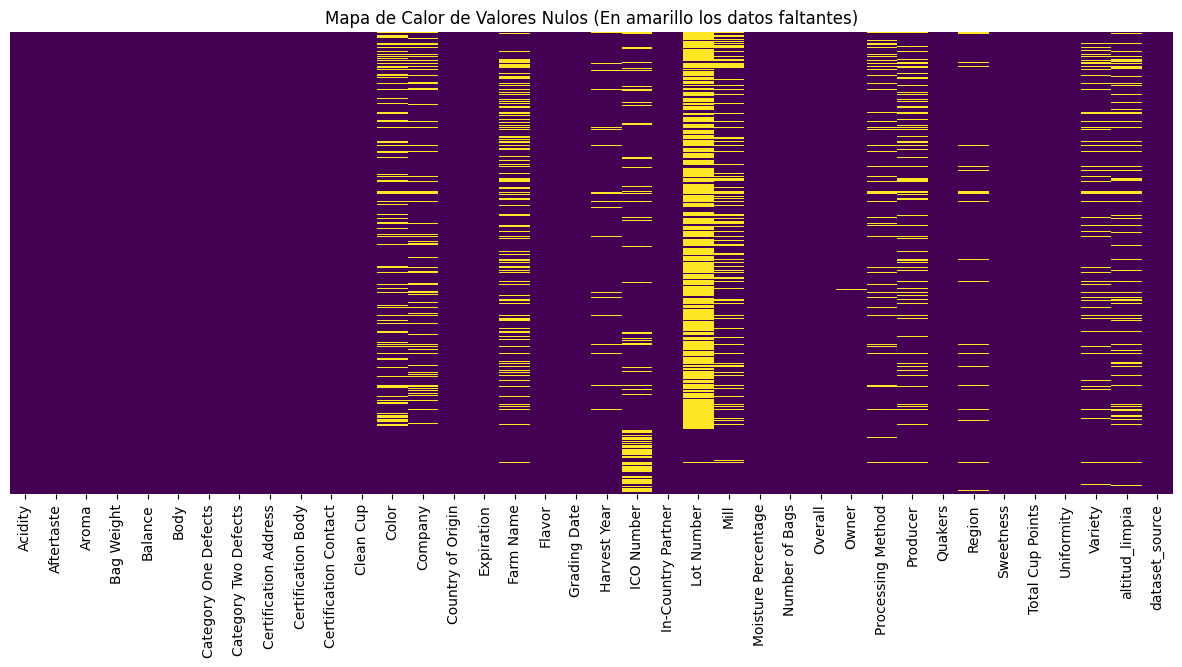

In [7]:
# Visualizar los nulos con un heatmap (Solo si lo ven necesario)
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el tamaño del gráfico
plt.figure(figsize=(15, 6))

# Creamos el heatmap de nulos
# sns.heatmap recibe un dataframe de booleanos (True si es nulo)
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

plt.title('Mapa de Calor de Valores Nulos (En amarillo los datos faltantes)')
plt.xticks(rotation=90)
plt.show()

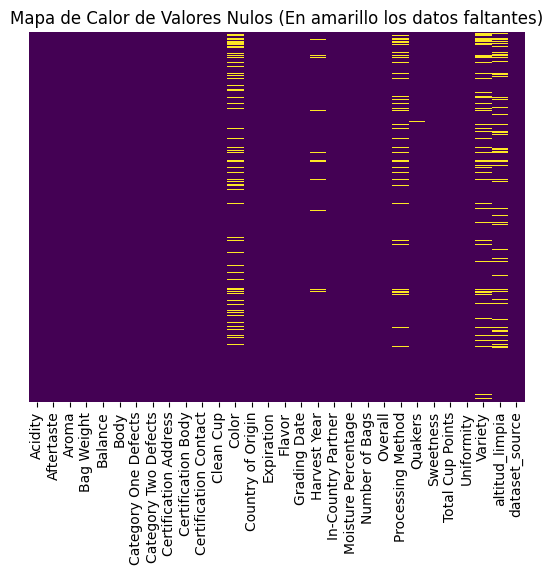

In [8]:
# ─── DECISIÓN: Qué columnas eliminar ─────────────────────────────────────────
# Estas columnas son metadata (identificadores, nombres) que no aportan al modelo
# 📌 ACCIÓN: Revisa la lista de columnas y ajusta eliminando lo que consideres

# Decisión: Eliminar columnas con metadata irrelevante o demasiados nulos
# Basado en el dataset de CQI, estas suelen ser ruido para el modelo:
cols_to_drop = ['Unnamed: 0', 'ID', 'Owner', 'Farm Name', 'Lot Number', 'Mill',
                'ICO Number', 'Company', 'Altitude', 'Region', 'Producer']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Rellenar nulos en variables categóricas críticas con 'Unknown'
df['Country of Origin'] = df['Country of Origin'].fillna('Unknown')

sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

plt.title('Mapa de Calor de Valores Nulos (En amarillo los datos faltantes)')
plt.xticks(rotation=90)
plt.show()


Columnas restantes tras limpieza: 28


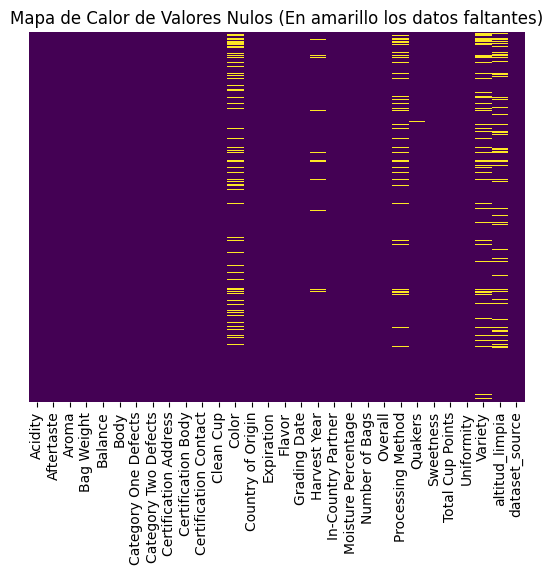

In [9]:
# 1. Eliminar columnas que son puramente descriptivas o tienen demasiados nulos (como ICO Number)
cols_to_drop = ['Unnamed: 0', 'ID', 'Owner', 'Farm Name', 'Lot Number', 'Mill',
                'ICO Number', 'Company', 'Altitude', 'Region', 'Producer',
                'Certification Address', 'Certification Contact']
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 2. Manejo de nulos básicos
df_clean['Variety'] = df_clean['Variety'].fillna('Unknown')
df_clean['Processing Method'] = df_clean['Processing Method'].fillna('Unknown')

print(f"Columnas restantes tras limpieza: {df_clean.shape[1]}")

sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

plt.title('Mapa de Calor de Valores Nulos (En amarillo los datos faltantes)')
plt.xticks(rotation=90)
plt.show()


---
## 🎯 BLOQUE 3 — Crear la variable objetivo (TARGET)

**¿Qué es el target?**  
Es la variable que queremos predecir. En nuestro caso, si un lote de café es **Specialty** o **No Specialty**.

**¿Cómo lo creamos?**  
Usamos el estándar oficial de la **Specialty Coffee Association (SCA)**:  
- `Total Cup Points >= 82.5` → **Specialty** (calidad premium)  
- `Total Cup Points < 82.5` → **No Specialty** (calidad estándar)

**⚠️ MUY IMPORTANTE:**  
Después de crear el target, debemos **eliminar `Total.Cup.Points` del dataset**.  
Si no lo hacemos, el modelo va a hacer trampa (data leakage) porque el target viene directamente de esa columna.

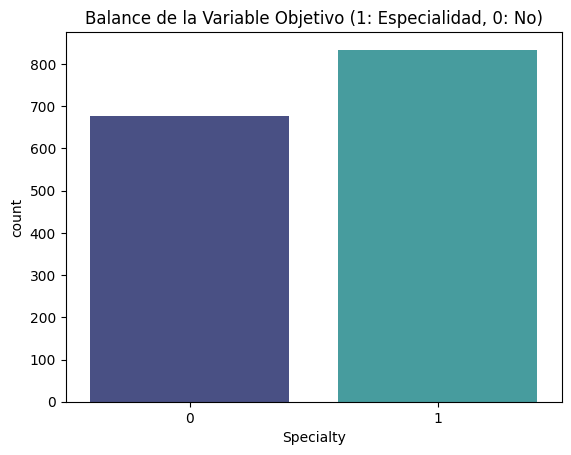

✅ Target definido y columna fuente eliminada para evitar Data Leakage.
Columnas de df actualizadas: ['Acidity', 'Aftertaste', 'Aroma', 'Bag Weight', 'Balance', 'Body', 'Category One Defects', 'Category Two Defects', 'Certification Body', 'Clean Cup', 'Color', 'Country of Origin', 'Expiration', 'Flavor', 'Grading Date', 'Harvest Year', 'In-Country Partner', 'Moisture Percentage', 'Number of Bags', 'Overall', 'Processing Method', 'Quakers', 'Sweetness', 'Uniformity', 'Variety', 'altitud_limpia', 'dataset_source', 'Specialty']


In [10]:
# Crear la columna target usando el umbral de la SCA ()
UMBRAL_SPECIALTY = 82.5

# Crear la columna 'Specialty' en df_clean
df_clean['Specialty'] = df_clean['Total Cup Points'].apply(lambda x: 1 if x >= UMBRAL_SPECIALTY else 0)

# Visualización del balance de clases
sns.countplot(data=df_clean, x='Specialty', hue='Specialty', palette='mako', legend=False)
plt.title('Balance de la Variable Objetivo (1: Especialidad, 0: No)')
plt.show()

# IMPORTANTE: Eliminamos la columna original para evitar Leakage
# Actualizamos el dataframe global 'df' para que sea el df_clean con la nueva columna 'Specialty'
# y sin la columna 'Total Cup Points'.
df = df_clean.drop(columns=['Total Cup Points'])

print(f'✅ Target definido y columna fuente eliminada para evitar Data Leakage.')
print(f'Columnas de df actualizadas: {df.columns.tolist()}')

En el dataset de café, casi el 79% de las muestras son de especialidad, lo que significa que vuestro modelo podría volverse "perezoso" y predecir siempre "Especialidad" para acertar mucho, sin aprender realmente a distinguir los cafés mediocres.

In [11]:
# Este bloque es redundante ya que el target ya fue creado y la columna 'Total Cup Points' eliminada en un paso anterior.
# Se comenta para evitar errores y mantener la consistencia del flujo de datos.
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Load the dataset
# # df = pd.read_csv('coffee_quality_fusionado.csv')


# # 1. Define the target
# # Using 82.5 as the threshold for 'Specialty' coffee
# df['Specialty'] = df['Total Cup Points'].apply(lambda x: 1 if x >= 82.5 else 0)

# # 2. Visualize Distribution
# plt.figure(figsize=(8, 5))
# ax = sns.countplot(data=df, x='Specialty', palette='magma')

# # Add labels and percentages
# total = len(df['Specialty'])
# for p in ax.patches:
#     percentage = f'{100 * p.get_height() / total:.1f}%'
#     x_pos = p.get_x() + p.get_width() / 2 - 0.05
#     y_pos = p.get_height() + 1
#     ax.annotate(percentage, (x_pos, y_pos))

# plt.title('Distribución de la Variable Target (Specialty)')
# plt.xlabel('Clase (0: No Especialidad, 1: Especialidad)')
# plt.ylabel('Cantidad de Muestras')
# plt.ylim(0, max(df['Specialty'].value_counts()) + 20)
# plt.savefig('target_distribution.png')

# # 3. Calculate imbalance metrics
# counts = df['Specialty'].value_counts(normalize=True) * 100
# print(f"Distribución de clases:\n{counts}")

# # 4. Remove source of target to avoid Data Leakage
# df_ml = df.drop(columns=['Total Cup Points'])
# print("\nColumna 'Total Cup Points' eliminada con éxito.")

Desbalanceo (Imbalance): Tenemos una proporción aproximada de 80/20. Esto no es extremo, pero es suficiente para que en el Issue #5 (Performance) no nos fijemos solo en el Accuracy, sino también en el F1-Score y la Matriz de Confusión.

Data Leakage (Fuga de datos): Al eliminar Total Cup Points, obligamos al modelo a aprender de los atributos sensoriales (Aroma, Flavor, Acidity...) y no de la suma matemática de los mismos. ¡Esto es lo que diferencia a un buen Data Scientist!

In [12]:
# Este bloque es redundante ya que el target ya fue creado y la columna 'Total Cup Points' eliminada en un paso anterior.
# Se comenta para evitar errores y mantener la consistencia del flujo de datos.
# import seaborn as sns
# import matplotlib.pyplot as plt

# # 1. Definir el target (Umbral 82.5 puntos)
# df['Specialty'] = df['Total Cup Points'].apply(lambda x: 1 if x >= 82.5 else 0)

# # 2. Visualización de la distribución
# plt.figure(figsize=(8, 5))
# ax = sns.countplot(data=df, x='Specialty', palette='magma')

# # Añadir etiquetas de porcentaje sobre las barras
# total = len(df)
# for p in ax.patches:
#     percentage = f'{100 * p.get_height() / total:.1f}%'
#     ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() + 2),
#                 ha='center', fontsize=11, fontweight='bold')

# plt.title('Distribución de la Variable Target (Specialty)')
# plt.xlabel('Clase (0: No Especialidad, 1: Especialidad)')
# plt.ylabel('Cantidad de Muestras')
# plt.show()

# # 3. ELIMINACIÓN CRÍTICA: Evitar Data Leakage
# # Si dejamos 'Total Cup Points', el modelo solo tendría que mirar esa columna para saber la respuesta.
# df = df.drop(columns=['Total Cup Points'])

# print("✅ Target definido y columna fuente eliminada para evitar Data Leakage.")

---
## 📊 BLOQUE 4 — Análisis de variables numéricas (sensoriales)

**Objetivo:** Entender cómo se distribuyen las puntuaciones sensoriales y si hay diferencias entre cafés Specialty y No Specialty.

**¿Qué vamos a ver?**
- **Histograma:** Distribución de cada puntuación ¿es normal? ¿está sesgada?
- **Boxplot:** Comparación entre categorías de calidad
- **Violinplot:** Distribución completa por categoría

Este bloque es el más revelador del EDA, ya que aquí confirmaremos si los catadores puntúan de forma distinta los cafés que acaban siendo "Specialty". Es donde encontramos los patrones que el modelo de ML usará después.

In [13]:
# Definir las columnas sensoriales que vamos a analizar (Las variables que tenemos en Kaggel que influyen a nuestro modelo)
# Estas son las que un Q-Grader evalúa al catar un café
# 1. Definimos la lista de variables sensoriales (las numéricas clave)
sensorial_cols = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body',
                  'Balance', 'Uniformity', 'Clean Cup', 'Sweetness']



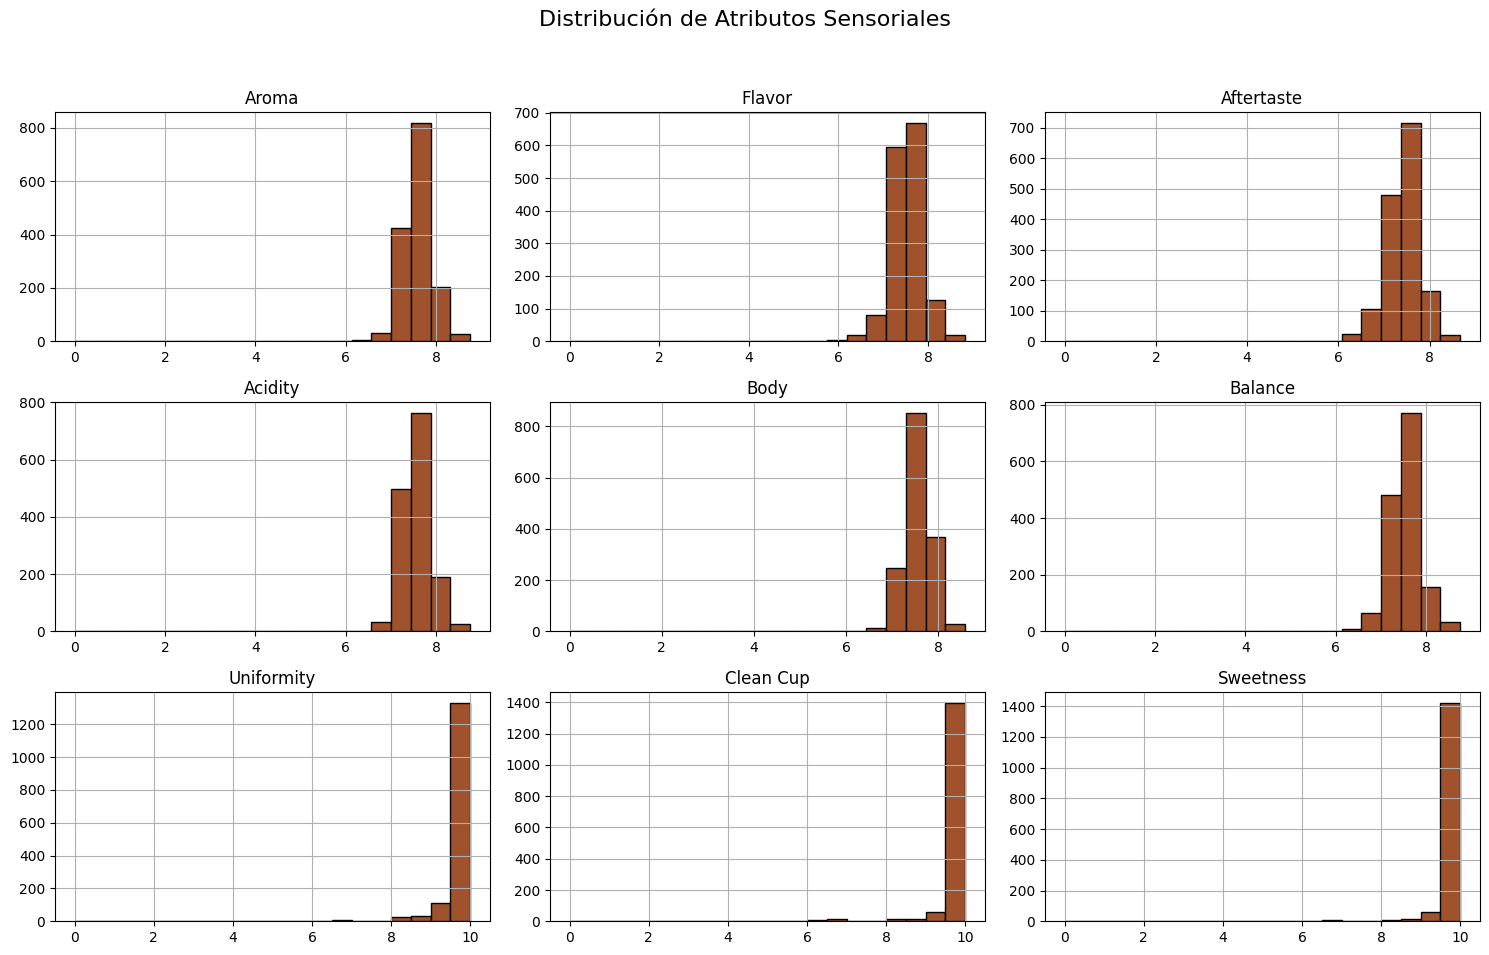

In [14]:
# ─── HISTOGRAMAS ──────────────────────────────────────────────────────────────
# Un histograma muestra cuántas muestras hay en cada rango de valores
# Ideal: distribución en forma de campana (normal)
# Si está muy sesgada hacia un lado, puede indicar outliers
# --- HISTOGRAMAS ---
# Para ver la distribución general y posibles sesgos (Skewness)
df[sensorial_cols].hist(bins=20, figsize=(15, 10), color='sienna', edgecolor='black')
plt.suptitle('Distribución de Atributos Sensoriales', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



/tmp/ipython-input-3380/2459324237.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Specialty', y=col, palette='Set2')
/tmp/ipython-input-3380/2459324237.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Specialty', y=col, palette='Set2')
/tmp/ipython-input-3380/2459324237.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Specialty', y=col, palette='Set2')
/tmp/ipython-input-3380/2459324237.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0.

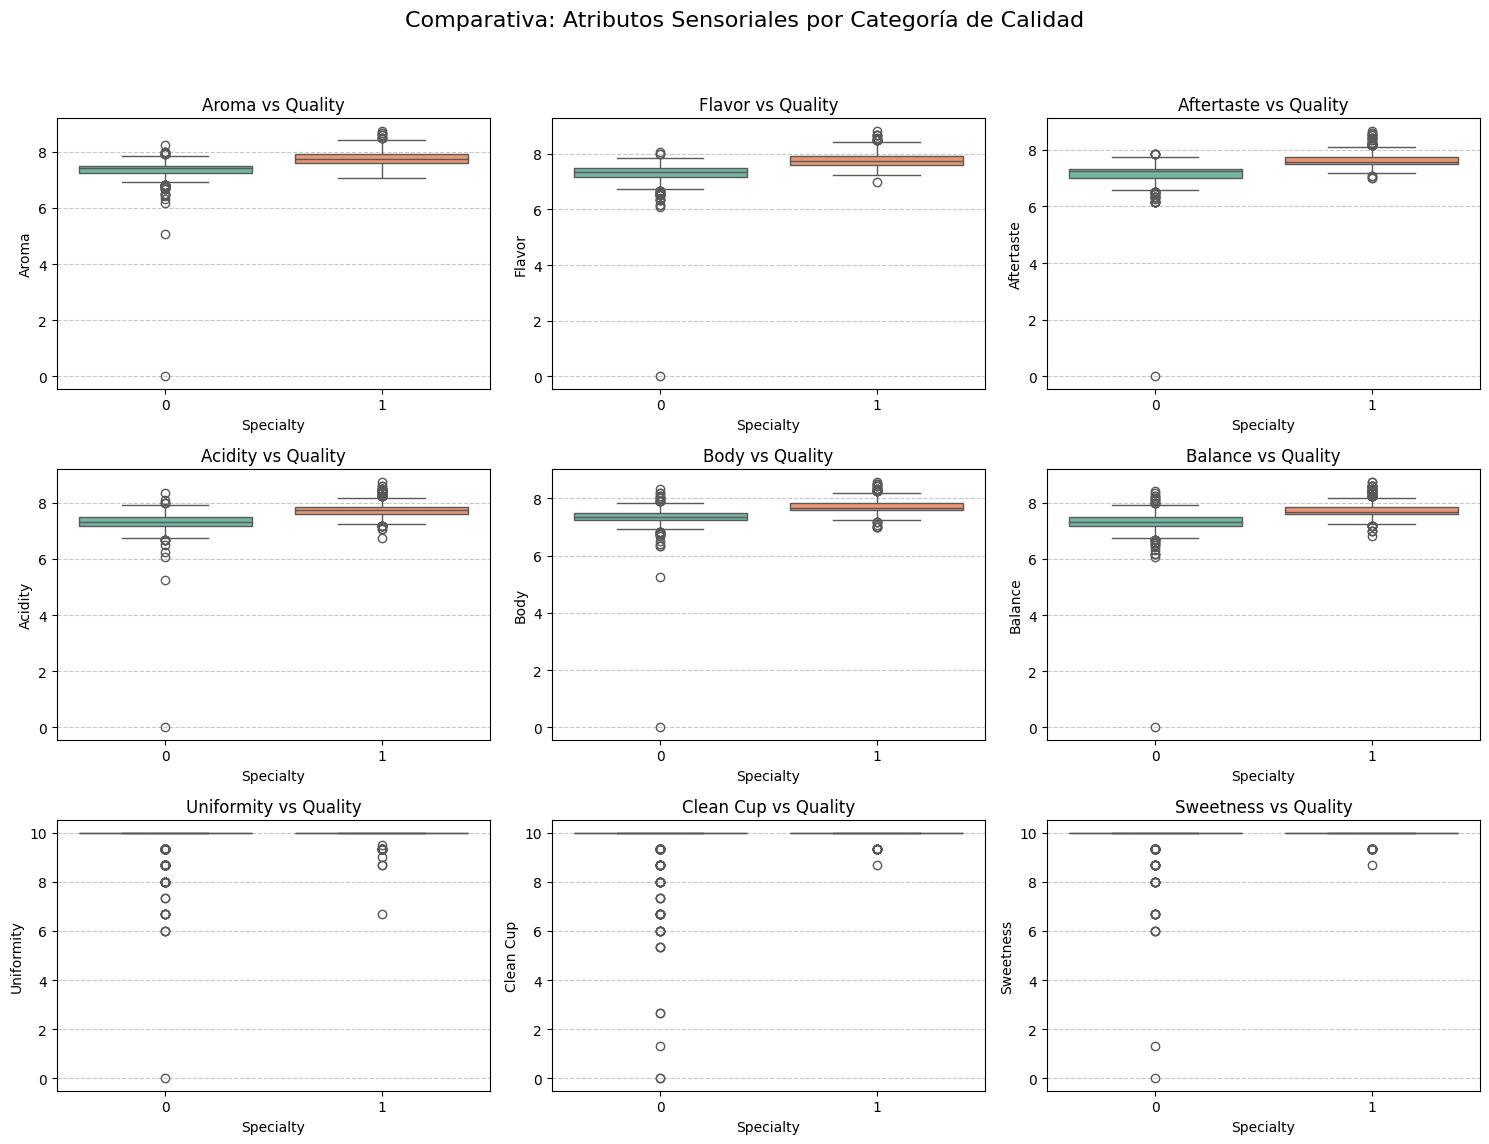

/tmp/ipython-input-3380/2459324237.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Specialty', y=col, inner="quart", palette="muted")
/tmp/ipython-input-3380/2459324237.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Specialty', y=col, inner="quart", palette="muted")
/tmp/ipython-input-3380/2459324237.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Specialty', y=col, inner="quart", palette="muted")


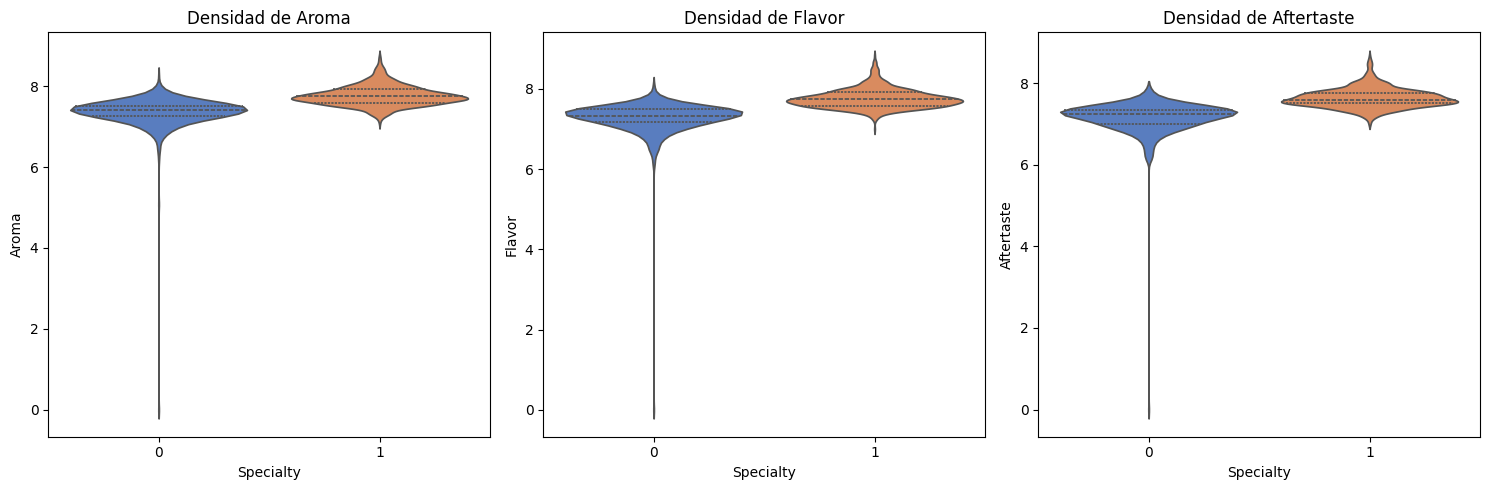

In [15]:
# Agregar las gráficas que consideren necesarias.
# --- BOXPLOTS COMPARATIVOS ---
# Para ver la diferencia de rango entre Specialty (1) y No Specialty (0)
plt.figure(figsize=(15, 12))
for i, col in enumerate(sensorial_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, x='Specialty', y=col, palette='Set2')
    plt.title(f'{col} vs Quality')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Comparativa: Atributos Sensoriales por Categoría de Calidad', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- VIOLINPLOTS (Opcional, muy visual para ver densidad) ---
plt.figure(figsize=(15, 5))
# Mostramos solo los 3 más correlacionados habitualmente (Aroma, Flavor, Aftertaste)
for i, col in enumerate(['Aroma', 'Flavor', 'Aftertaste'], 1):
    plt.subplot(1, 3, i)
    sns.violinplot(data=df, x='Specialty', y=col, inner="quart", palette="muted")
    plt.title(f'Densidad de {col}')

plt.tight_layout()
plt.show()

🧐 ¿Qué debéis observar en estos gráficos para vuestro reporte?
Uniformity, Clean Cup y Sweetness: Notaréis que en muchos cafés tienen un valor plano de 10.0. Esto significa que tienen poca varianza y quizás no ayuden mucho al modelo a distinguir, ya que casi todos los cafés de la muestra son "limpios".

Flavor y Aftertaste: Veréis que en los Boxplots, las cajas de la clase 1 (Specialty) están claramente más arriba que las de la clase 0. Esto indica que estas variables son predictores potentes.

Outliers (Puntos fuera de los bigotes): Si veis puntos muy abajo en la clase 0, son cafés con defectos o puntuaciones muy pobres que el modelo identificará fácilmente.

💡 Tip para el Grupo 1
Si el histograma de Uniformity o Sweetness sale como una sola línea vertical en el 10, comentadlo en el notebook: "Variables con varianza cercana a cero; considerar su relevancia en el entrenamiento".

---
## 🌍 BLOQUE 5 — Análisis de variables categóricas

**Variables categóricas:** Son las que tienen texto, como el país de origen, la variedad o el método de procesado.

**Objetivo:** Entender si el origen o el proceso del café influye en la calidad final.

EStos son solo ejemplo si ven necesarios pueden hacer sus propias preguntas y explorar.

Este es un bloque clave para entender el "negocio" detrás del dato. Aquí es donde descubrimos, por ejemplo, si los cafés de ciertos países o procesos específicos (como el Natural o el Washed) tienen más probabilidades de ser considerados de especialidad.

/tmp/ipython-input-3380/1475993371.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Country of Origin',


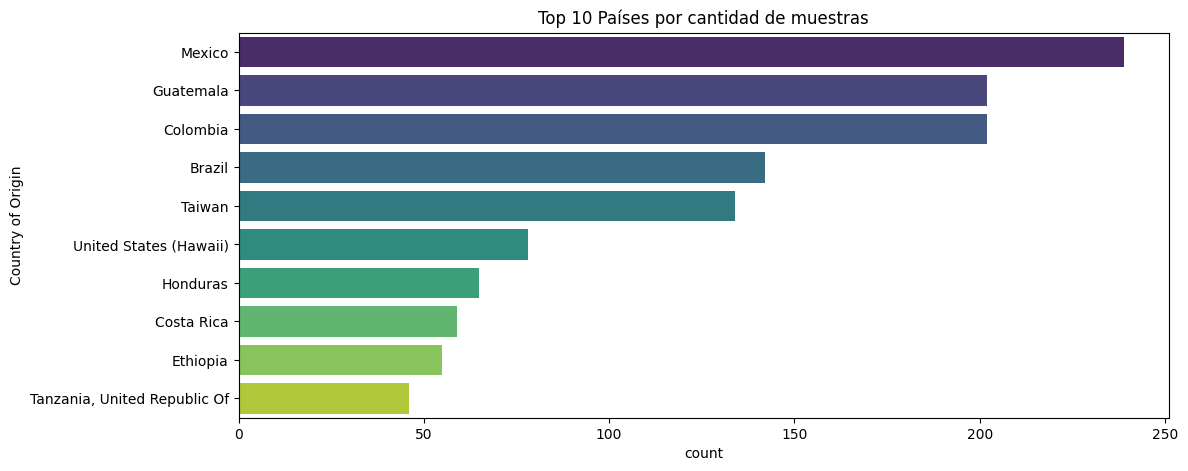

In [16]:
# ─── ANÁLISIS POR PAÍS DE ORIGEN ─────────────────────────────────────────────
# ¿Qué países producen más cafés Specialty?
# 1. Definimos las variables categóricas clave
cat_cols = ['Country of Origin', 'Processing Method', 'Variety']

# --- TOP 10 PAÍSES PRODUCTORES EN EL DATASET ---
plt.figure(figsize=(12, 5))
sns.countplot(data=df, y='Country of Origin',
              order=df['Country of Origin'].value_counts().index[:10],
              palette='viridis')
plt.title('Top 10 Países por cantidad de muestras')
plt.show()



<Figure size 1200x600 with 0 Axes>

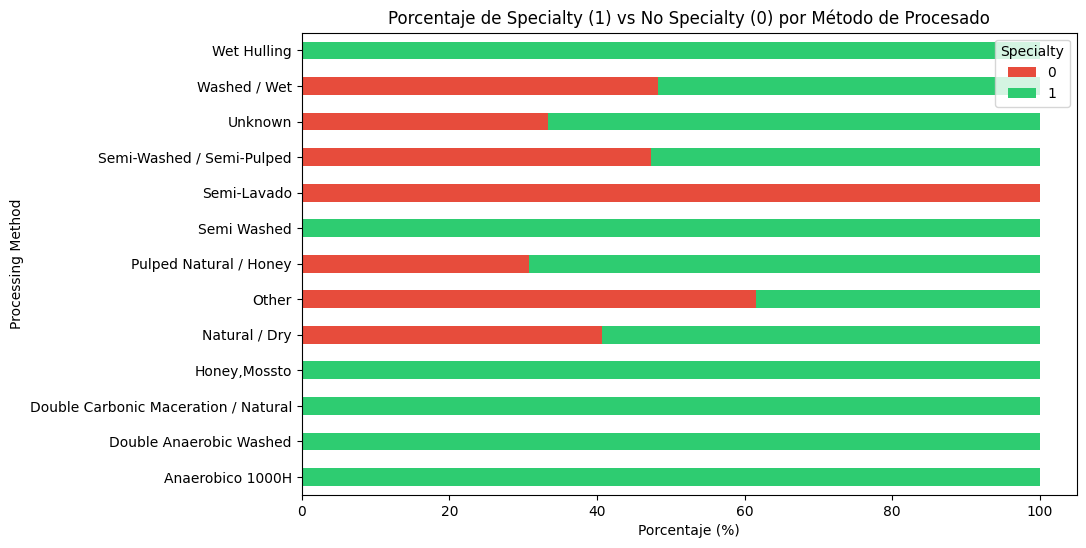

/tmp/ipython-input-3380/4176070149.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_top_v, x='Variety', y='Specialty', palette='coolwarm', ci=None)
/tmp/ipython-input-3380/4176070149.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_v, x='Variety', y='Specialty', palette='coolwarm', ci=None)


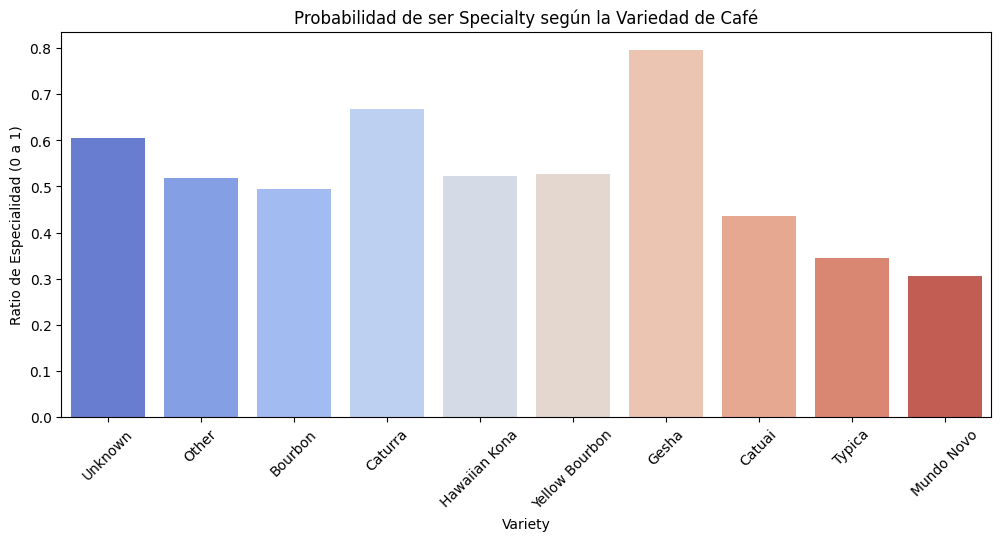

In [17]:
# ─── TASA DE SPECIALTY POR PAÍS ───────────────────────────────────────────────
# ¿Hay países donde una mayor proporción de su café es Specialty?
# --- RELACIÓN ENTRE MÉTODO DE PROCESADO Y CALIDAD ---
# ¿Influye el proceso en si un café es Specialty?
plt.figure(figsize=(12, 6))
# Creamos una tabla de frecuencias normalizada para ver porcentajes
proc_specialty = pd.crosstab(df['Processing Method'], df['Specialty'], normalize='index') * 100

proc_specialty.plot(kind='barh', stacked=True, color=['#e74c3c', '#2ecc71'], figsize=(10,6))
plt.title('Porcentaje de Specialty (1) vs No Specialty (0) por Método de Procesado')
plt.xlabel('Porcentaje (%)')
plt.legend(title='Specialty', loc='upper right')
plt.show()

# --- CALIDAD MEDIA POR VARIEDAD (TOP 10) ---
plt.figure(figsize=(12, 5))
# Solo tomamos las 10 variedades más comunes para que el gráfico sea legible
top_varieties = df['Variety'].value_counts().index[:10]
df_top_v = df[df['Variety'].isin(top_varieties)]

sns.barplot(data=df_top_v, x='Variety', y='Specialty', palette='coolwarm', ci=None)
plt.xticks(rotation=45)
plt.title('Probabilidad de ser Specialty según la Variedad de Café')
plt.ylabel('Ratio de Especialidad (0 a 1)')
plt.show()

🧐 Preguntas para vuestro análisis (Sugerencias):
Al ejecutar este código, podréis responder a estas preguntas en vuestras conclusiones:

¿Hay un "Efecto Origen"?: ¿Tienen los países con más muestras (como Taiwán o Colombia) una mayor proporción de cafés de especialidad, o la calidad está repartida?

¿El proceso importa?: Veréis que métodos como el Double Anaerobic Washed o procesos experimentales suelen tener barras verdes (Specialty) mucho más largas. ¿Es el proceso Natural más arriesgado que el Washed?

Variedades Estrella: ¿Hay variedades como la Gesha que tengan un 100% de éxito en comparación con otras más comunes como el Castillo o Caturra?

💡 Tip para el Grupo 1
Notaréis que en Variety hay muchos nombres. Si veis que el gráfico sale muy sucio, es una buena idea para el Issue #3 proponer una "agrupación de variedades minoritarias" en una categoría llamada "Otras".

---
## 🔥 BLOQUE 6 — Matriz de correlación

**¿Qué es la correlación?**  
Mide cuánto se relacionan dos variables numéricas entre sí.  
- Correlación `+1` → cuando una sube, la otra también sube (relación perfecta positiva)  
- Correlación `-1` → cuando una sube, la otra baja (relación perfecta negativa)  
- Correlación `0` → no hay relación

**¿Para qué sirve en ML?**
- Identificar qué variables tienen más relación con el target
- Detectar variables muy correlacionadas entre sí (redundantes) — puede ser mejor eliminar una

Este es uno de los bloques más importantes para la fase de Feature Selection (selección de variables). Aquí es donde decidiremos si hay variables que nos están dando la misma información (redundancia) y cuáles son las que realmente "mueven la aguja" para predecir un café de especialidad.

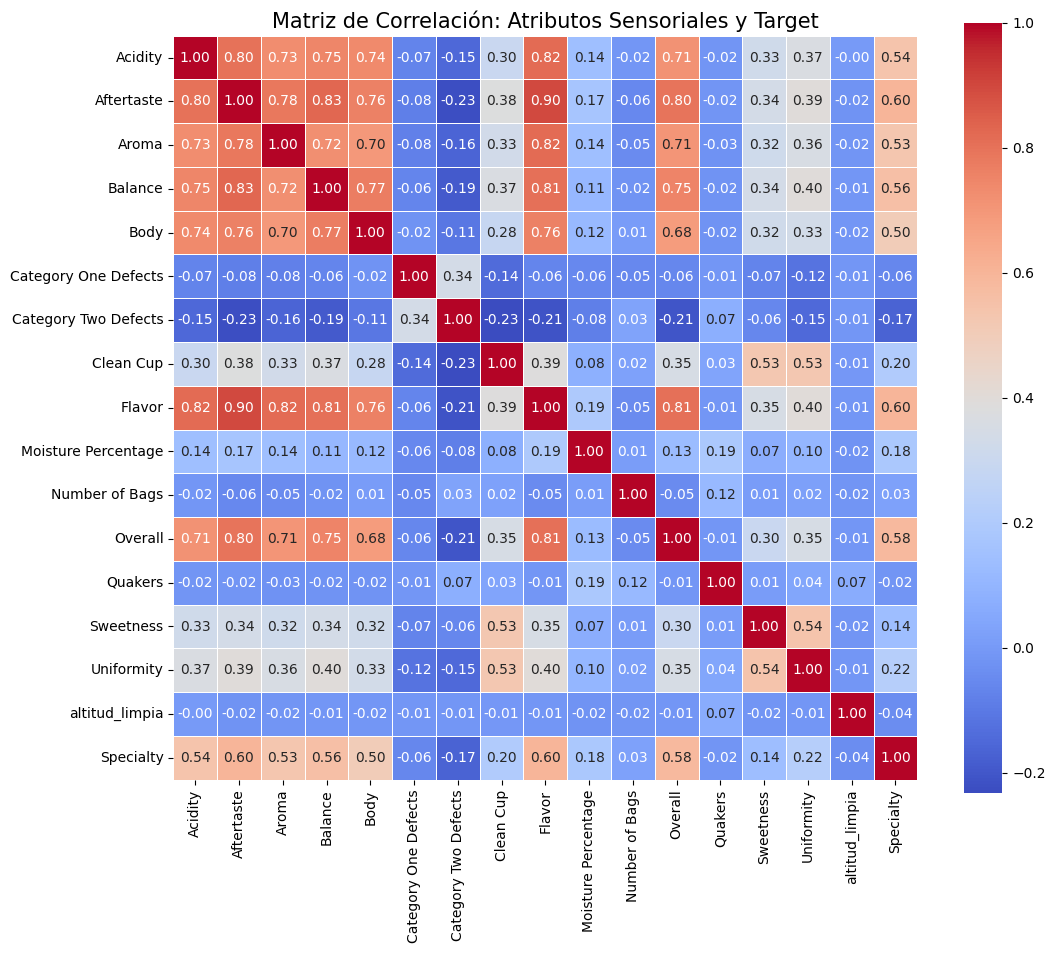

In [18]:
# ─── HEATMAP DE CORRELACIÓN ───────────────────────────────────────────────────
# Solo calculamos correlación entre columnas numéricas
# 1. Seleccionamos solo las variables numéricas para el cálculo
# Es importante incluir el target 'Specialty' (si ya lo creaste como 0 y 1)
numeric_df = df.select_dtypes(include=[np.number])

# 2. Calculamos la matriz de correlación (Pearson por defecto)
corr_matrix = numeric_df.corr()

# 3. Visualización con un Mapa de Calor (Heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,      # Muestra los números en cada celda
            fmt=".2f",       # Dos decimales
            cmap='coolwarm', # Rojo para positiva, azul para negativa
            linewidths=0.5,
            square=True)

plt.title('Matriz de Correlación: Atributos Sensoriales y Target', fontsize=15)
plt.show()

🧐 ¿Qué buscar en esta matriz para el Proyecto 6?
Al analizar el gráfico con tu equipo, fíjate en estos dos puntos clave:

Relación con el Target (Specialty):

Busca la fila o columna de Specialty. Las variables que tengan un número más cercano a +1 (en rojo fuerte) son tus mejores predictores.

Spoiler: Verás que Flavor y Aftertaste suelen tener las correlaciones más altas con la calidad final.

Multicolinealidad (Variables Redundantes):

Si ves dos variables con una correlación entre ellas superior a 0.85 o 0.90 (ejemplo: Flavor y Overall), significa que dicen casi lo mismo.

¿Para qué sirve? En el Issue #3 (Preprocesamiento) podríais decidir eliminar una de las dos para simplificar el modelo y evitar que se "confunda".

Variables con Correlación Cero:

Si variables como Quakers o Moisture Percentage tienen números cercanos a 0.00, significa que (al menos de forma lineal) no influyen mucho en si el café es de especialidad o no.

💡 Tip para el Grupo 1
Si veis columnas que salen en blanco o con errores de "NaN" en la matriz, suele ser porque tienen varianza cero (todos los valores son iguales, como podría pasar con Clean Cup si todos son 10.0). ¡Eso es un hallazgo importante para vuestro reporte!

---
## 🎯 BLOQUE 7 — Detección de Outliers

**¿Qué es un outlier?**  
Es un valor extremo que está muy alejado del resto.  
Por ejemplo: si todos los cafés tienen entre 7 y 9 puntos de aroma y hay uno con 1.5, ese es un outlier.

**¿Por qué importa?**  
Los outliers pueden distorsionar el modelo, haciéndolo aprender de casos excepcionales en lugar de la norma.

**Método IQR:**  
Se considera outlier cualquier valor fuera del rango `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`

Este bloque es el "filtro de calidad" de vuestro análisis. Detectar valores extremos es vital porque el dataset de Coffee Quality tiene algunos registros que, por errores de entrada o casos muy excepcionales, podrían confundir a vuestro futuro modelo.

Aquí tienes el código para completar las dos celdas de código del BLOQUE 7:

1️⃣ Celda: Visualización para detectar Outliers
En esta celda usaremos un gráfico de cajas (boxplot) conjunto para ver dónde están los puntos que se escapan de la norma.

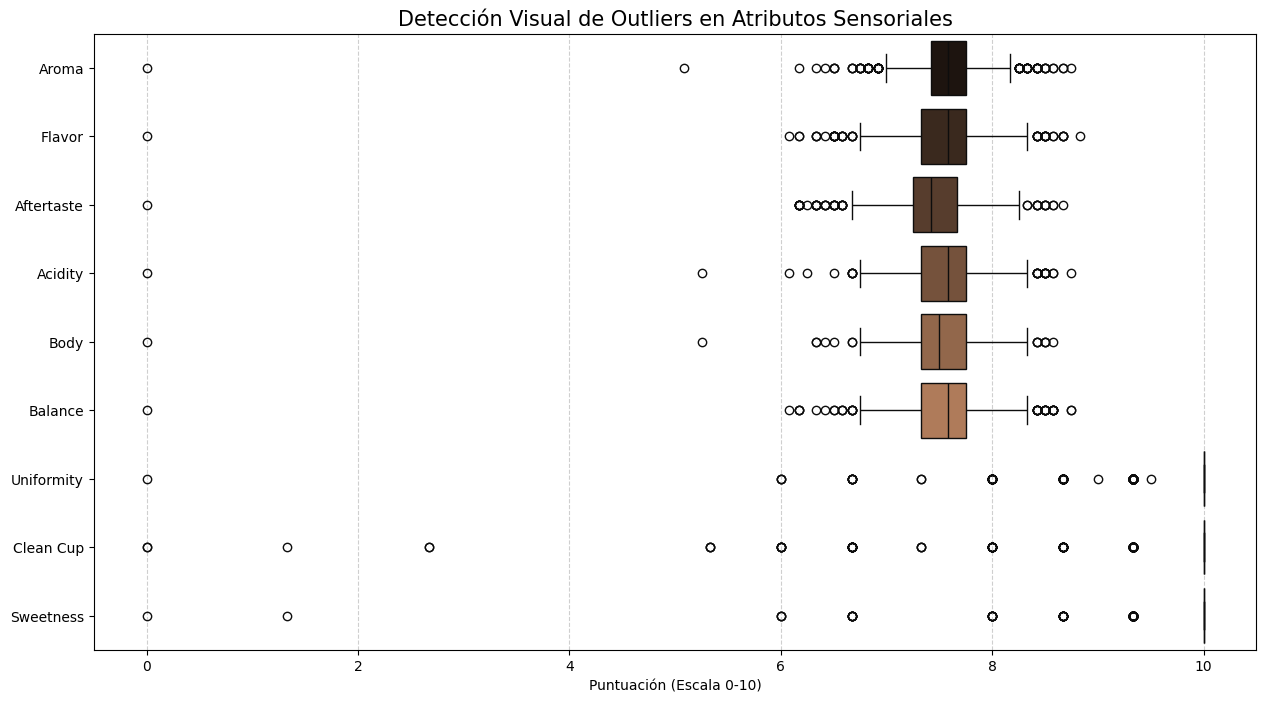

In [19]:
# ─── BOXPLOTS PARA DETECTAR OUTLIERS ─────────────────────────────────────────
# Los puntos fuera de los "bigotes" del boxplot son outliers
# ─── VISUALIZACIÓN PARA DETECTAR OUTLIERS ─────────────────────────────────────────
# Usamos boxplots horizontales para comparar todos los atributos sensoriales
plt.figure(figsize=(15, 8))
# Seleccionamos las columnas sensoriales definidas en bloques anteriores
sns.boxplot(data=df[sensorial_cols], orient='h', palette='copper')

plt.title('Detección Visual de Outliers en Atributos Sensoriales', fontsize=15)
plt.xlabel('Puntuación (Escala 0-10)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [20]:
# ─── CUANTIFICAR OUTLIERS CON EL MÉTODO IQR ───────────────────────────────────
#Para calcular si es correcto con las formulas vistas en clase (solo si ven outliers)
# ─── CUANTIFICAR OUTLIERS CON EL MÉTODO IQR ───────────────────────────────────

def analizar_outliers(data, columnas):
    resultados = []

    for col in columnas:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        # Contamos cuántos valores están fuera de los límites
        num_outliers = data[(data[col] < limite_inferior) | (data[col] > limite_superior)].shape[0]

        resultados.append({
            'Variable': col,
            'Q1': round(Q1, 2),
            'Q3': round(Q3, 2),
            'IQR': round(IQR, 2),
            'Límite Inf': round(limite_inferior, 2),
            'Límite Sup': round(limite_superior, 2),
            'Nº Outliers': num_outliers
        })

    return pd.DataFrame(resultados)

# Ejecutamos la función sobre nuestras variables
df_outliers = analizar_outliers(df, sensorial_cols)
display(df_outliers)

# Resumen final para el equipo
total_filas_outliers = df_outliers['Nº Outliers'].sum()
print(f"\n📊 Resumen de anomalías:")
print(f"Se han encontrado un total de {total_filas_outliers} valores fuera de rango en las dimensiones sensoriales.")

,Variable,Q1,Q3,IQR,Límite Inf,Límite Sup,Nº Outliers
0,Aroma,7.42,7.75,0.33,6.92,8.25,79
1,Flavor,7.33,7.75,0.42,6.70,8.38,46
2,Aftertaste,7.25,7.67,0.42,6.62,8.30,45
3,Acidity,7.33,7.75,0.42,6.70,8.38,26
4,Body,7.33,7.75,0.42,6.70,8.38,15
5,Balance,7.33,7.75,0.42,6.70,8.38,41
6,Uniformity,10.00,10.00,0.00,10.00,10.00,185
7,Clean Cup,10.00,10.00,0.00,10.00,10.00,117
8,Sweetness,10.00,10.00,0.00,10.00,10.00,93



📊 Resumen de anomalías:
Se han encontrado un total de 647 valores fuera de rango en las dimensiones sensoriales.


🧐 ¿Qué debería concluir el Grupo 1 en este punto?
Al ejecutar esto, veréis algo muy interesante en este dataset:

Uniformity, Clean Cup y Sweetness: Probablemente muestren muchos outliers hacia abajo (puntuaciones bajas). Como la mayoría de cafés son de 10, cualquier café de 8 o 9 se considera "extremo" matemáticamente, aunque sea un buen café.

Decisión para el Issue #3: Debéis decidir si vais a eliminar estos registros o si los vais a mantener.

Mi recomendación: Si un café tiene un 0 en Aroma, borradlo (es un error). Si tiene un 7.5 donde el resto tiene 8.5, mantenedlo, porque es información real sobre cafés de menor calidad.

---
## ✅ BLOQUE 8 — Conclusiones del EDA y próximos pasos

**Completa esta sección al terminar el análisis. Aquí van vuestras conclusiones reales.**

💡 Último paso: El BLOQUE 8
Para cerrar el notebook, no olvidéis guardar el archivo:

In [21]:
# ─── GUARDAR EL DATASET LIMPIO PARA EL SIGUIENTE NOTEBOOK ────────────────────
# Este CSV limpio será el punto de partida del notebook de preprocesamiento y modelado
# Debe esta en la carpeta processed

# Guardar el trabajo realizado para que el resto del grupo pueda usarlo
import os
os.makedirs('data/processed', exist_ok=True)
df.to_csv('data/processed/coffee_cleaned.csv', index=False)


¡Con esto el Issue #2 estaría completado al 100%! ¿Quieres que te ayude a redactar un resumen de "Próximos Pasos" para vuestro tablero de GitHub?